# Week 2 — OpenCV + NumPy Image Processing Workbook

## Source-integrated practice

This workbook combines:

1. the Month 1 Computer Vision roadmap,
2. the uploaded Kaggle tutorial **OpenCV Tutorial: From Basic to Advanced**,
3. additional hands-on exercises designed for independent practice.

**Source notebook:**  
https://www.kaggle.com/code/talhabu/opencv-tutorial-from-basic-to-advanced

The Kaggle tutorial covers image loading/display, grayscale, masking, color-channel splitting/merging, grayscale and color histograms, histogram equalization, blurring, thresholding, gradients, Canny edges, contours, geometric transformations, morphology, and bitwise operations.

**Rule:** Learn the concept → close the example → write your own version → compare results.


# 0 — Setup

### Suggested folder structure

```text
week_2_opencv/
│
├── notebook.ipynb
├── images/
├── outputs/
└── experiments/
```

Use your own architectural / urban image when possible.

For the first exercises, do not use AI to generate the complete code before your own attempt.


In [110]:
from turtledemo.chaos import plot

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.cluster import hierarchy

IMAGE_PATH = Path("images/test.jpg")
OUTPUT_DIR = Path("cv_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("OpenCV:", cv2.__version__)


OpenCV: 5.0.0


# PART 1 — IMAGE BASICS

## Exercise 1 — Read and Inspect

Use `cv2.imread()`.

Inspect:

- type
- shape
- dtype
- min
- max
- mean

Also check whether loading failed.


In [111]:
# TODO
# read the image using OpenCV
img=cv2.imread("images/test.jpg")


## Exercise 2 — BGR vs RGB

OpenCV loads color images as **BGR** by default.

1. Print one pixel from the image.
2. Convert BGR → RGB with `cv2.cvtColor`.
3. Show the image correctly with Matplotlib.
4. Show what happens when you pass the BGR image directly to Matplotlib.

Explain the color difference.


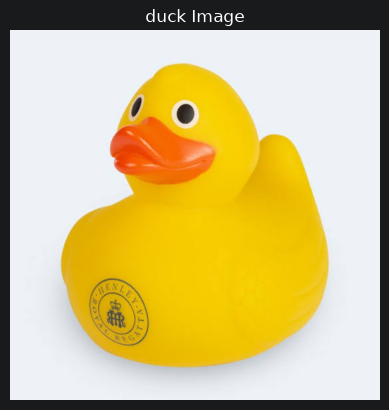

In [112]:
# TODO
# convert the color from BGR to RGB for displaying using matplotlib
img_rgb=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# display the image using matplotlib
plt.imshow(img_rgb)
plt.title("duck Image")
plt.axis('off')
plt.show()

## Exercise 3 — Grayscale

Create a grayscale image with `cv2.cvtColor`.

Inspect:

- original shape
- grayscale shape
- original dtype
- grayscale dtype

Explain why `(H, W, 3)` becomes `(H, W)`.


(np.float64(-0.5), np.float64(553.5), np.float64(553.5), np.float64(-0.5))

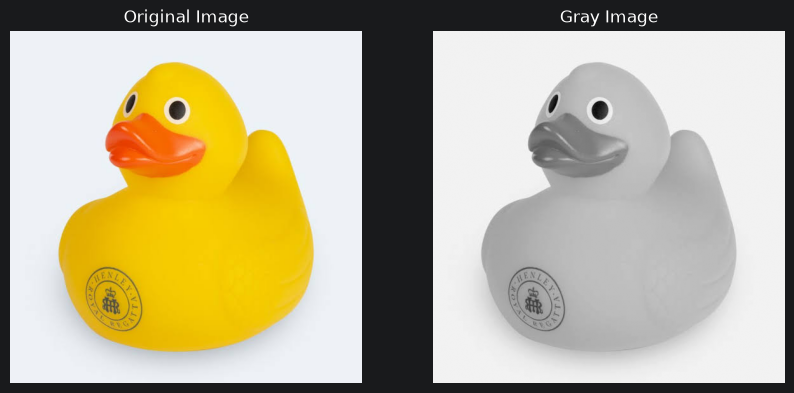

In [113]:
# TODO
img=img_rgb

# Converting the image to grayscale
img_gray=cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

fig, axs = plt.subplots(1,2,figsize=(10,10))
axs[0].imshow(img)
axs[0].set_title("Original Image")
axs[1].imshow(img_gray,cmap="gray")
axs[1].set_title("Gray Image")
axs[0].axis('off')
axs[1].axis('off')


## Exercise 4 — NumPy vs OpenCV Grayscale

You previously created grayscale using a simple channel average:

`image.mean(axis=2)`

Now compare that result with:

`cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)`

Do not expect the values to be identical.

Write one sentence explaining why.


(np.float64(-0.5), np.float64(553.5), np.float64(553.5), np.float64(-0.5))

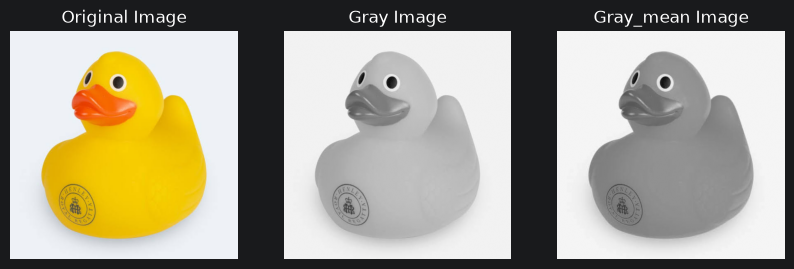

In [114]:
# TODO
gray_mean = img.mean(axis=2)# additional grayscale method
# Converting the image to grayscale
img_gray=cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

fig, axs = plt.subplots(1,3,figsize=(10,10))
axs[0].imshow(img)
axs[0].set_title("Original Image")
axs[1].imshow(img_gray,cmap="gray")
axs[1].set_title("Gray Image")
axs[2].imshow(gray_mean,cmap="gray")
axs[2].set_title("Gray_mean Image")
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')

# PART 2 — IMAGE MASKING

The source tutorial describes masking as a way to isolate a region of interest (ROI) using a binary mask.

Typical binary-mask values are:

- `0` → excluded
- `255` → selected


## Exercise 5 — Rectangular Mask

1. Create a black mask with the same height and width as the image.
2. Make a rectangular region white.
3. Apply the mask to the image with a bitwise operation.
4. Display original, mask, and result.

Do not copy a ready-made solution; build it from the indexing/masking logic you already learned.


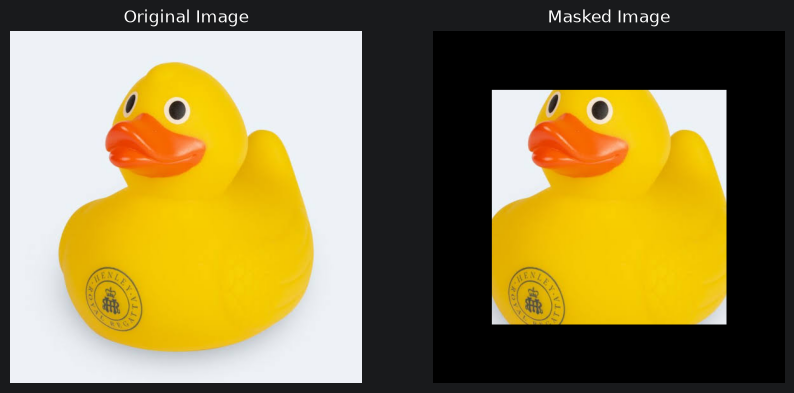

In [115]:
"""
1-Learning approach
    ↓
supervised / unsupervised / reinforcement

2-Model / neural network
    ↓
neural network

3-Architecture
    ↓
MLP / CNN / RNN / Transformer
    ↓
specific designs
ResNet / ViT / etc."""

# TODO
# Create a black mask with the same size as the image
mask=np.zeros_like(img)

# Define the measurements of rectangle
height, width = img.shape[:2] #[h,w,c] --> (h,w)
x1=width//2 -width//3
x2=width//2 +width//3
y1=height//2 -height//3
y2=height//2 +height//3


# Draw a white circle in the mask
cv2.rectangle(mask, (x1,y1), (x2,y2), (255, 255, 255), -1)

# Apply the mask to the image
masked_image = cv2.bitwise_and(img, mask)

# Display the original image with the circular mask
fig,axs= plt.subplots(1,2,figsize=(10, 5))
axs[0].imshow(img)
axs[0].set_title("Original Image")
axs[1].imshow(masked_image)
axs[1].set_title("Masked Image")
axs[0].axis('off')
axs[1].axis('off')
plt.show()


Number of contours: 1


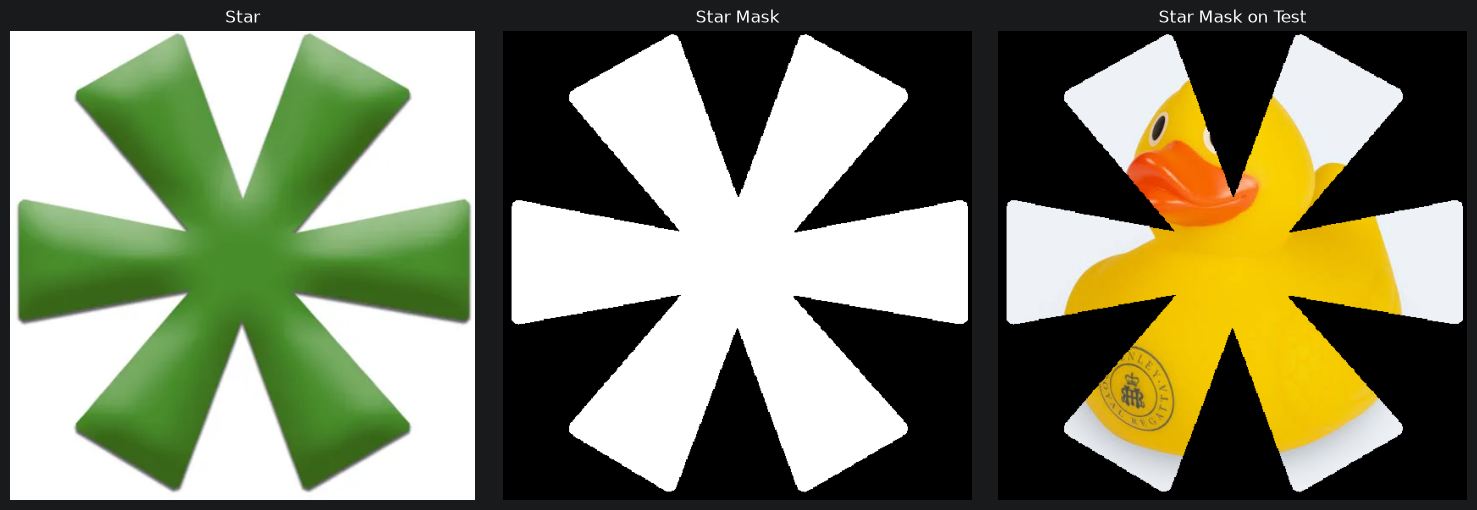

In [116]:
# --------------------------------------------------
# 1. Read images
# --------------------------------------------------

star = cv2.imread("images/star.png")
test = cv2.imread("images/test.jpg")

# --------------------------------------------------
# 2. STAR IMAGE -> binary
# --------------------------------------------------

star_gray = cv2.cvtColor(star, cv2.COLOR_BGR2GRAY)

_, star_binary = cv2.threshold(
    star_gray,
    200, # threshold value determines wheter the pixel is 0 or 255
    255, # max value
    cv2.THRESH_BINARY_INV
)

# --------------------------------------------------
# 3. Find star contour
# --------------------------------------------------

contours, hierarchy = cv2.findContours(
    star_binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours:", len(contours))

# Largest contour
star_contour = max(contours, key=cv2.contourArea)

# --------------------------------------------------
# 4. Create STAR mask
# --------------------------------------------------

star_mask = np.zeros_like(star_gray)

cv2.drawContours(
    star_mask,
    [star_contour],
    -1,
    255,
    -1
)

# --------------------------------------------------
# 5. Resize STAR mask to TEST image size
# --------------------------------------------------

test_h, test_w = test.shape[:2]

mask = cv2.resize(
    star_mask,
    (test_w, test_h),
    interpolation=cv2.INTER_NEAREST
)

# --------------------------------------------------
# 6. Apply STAR mask to TEST image
# --------------------------------------------------

masked_test = cv2.bitwise_and(
    test,
    test,
    mask=mask
)

# --------------------------------------------------
# 7. Display
# --------------------------------------------------

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(
    cv2.cvtColor(star, cv2.COLOR_BGR2RGB)
)
axs[0].set_title("Star")

axs[1].imshow(
    mask,
    cmap="gray"
)
axs[1].set_title("Star Mask")

axs[2].imshow(
    cv2.cvtColor(masked_test, cv2.COLOR_BGR2RGB)
)
axs[2].set_title("Star Mask on Test")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Exercise 6 — Mask a Meaningful Region

Choose something meaningful in the image:

- facade
- window
- road
- vehicle
- sign

Create a mask for that region and save the result.

Explain why an ROI mask might be useful in a CV pipeline.


In [117]:
# TODO
duck_img = cv2.imread("images/test.jpg")

duck_hsv = cv2.cvtColor(duck_img, cv2.COLOR_BGR2HSV)

samples = []
def mause_callback(event, x, y, flags, param):

    if event == cv2.EVENT_LBUTTONDOWN:
        H, S, V = duck_hsv[y, x]
        samples.append((x, y, H, S, V))

        print(
            f"Clicked: (x={x}, y={y}) | "
            f"HSV=({H}, {S}, {V})"
        )



cv2.namedWindow("Image")
cv2.setMouseCallback("Image", mause_callback)
while True:
    # Her frame'de orijinal görüntüden yeniden başla
    display = duck_img.copy()
    # Daha önce tıklanan noktaları ve bilgilerini göster
    for i, (x, y, H, S, V) in enumerate(samples, start=1):

        cv2.circle(display, (x, y), 3, (255, 255, 255), -1)

        cv2.putText(
            display,
            f"#{i} ({x},{y}) HSV:{H},{S},{V}",
            (x + 5, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 255),
            1
        )
    cv2.imshow("Image", display)

    key = cv2.waitKey(20) & 0xFF

    # ESC
    if key == 27:
        break

    # X ile kapatıldı mı?
    if cv2.getWindowProperty("Image", cv2.WND_PROP_VISIBLE) < 1:
        break

cv2.destroyAllWindows()




Clicked: (x=169, y=163) | HSV=(7, 211, 234)
Clicked: (x=170, y=194) | HSV=(8, 255, 232)
Clicked: (x=179, y=200) | HSV=(8, 147, 244)
Clicked: (x=202, y=202) | HSV=(11, 180, 255)
Clicked: (x=216, y=214) | HSV=(14, 253, 241)
Clicked: (x=233, y=174) | HSV=(13, 254, 247)
Clicked: (x=198, y=153) | HSV=(12, 255, 241)
Clicked: (x=180, y=159) | HSV=(9, 252, 244)
Clicked: (x=162, y=162) | HSV=(6, 204, 232)


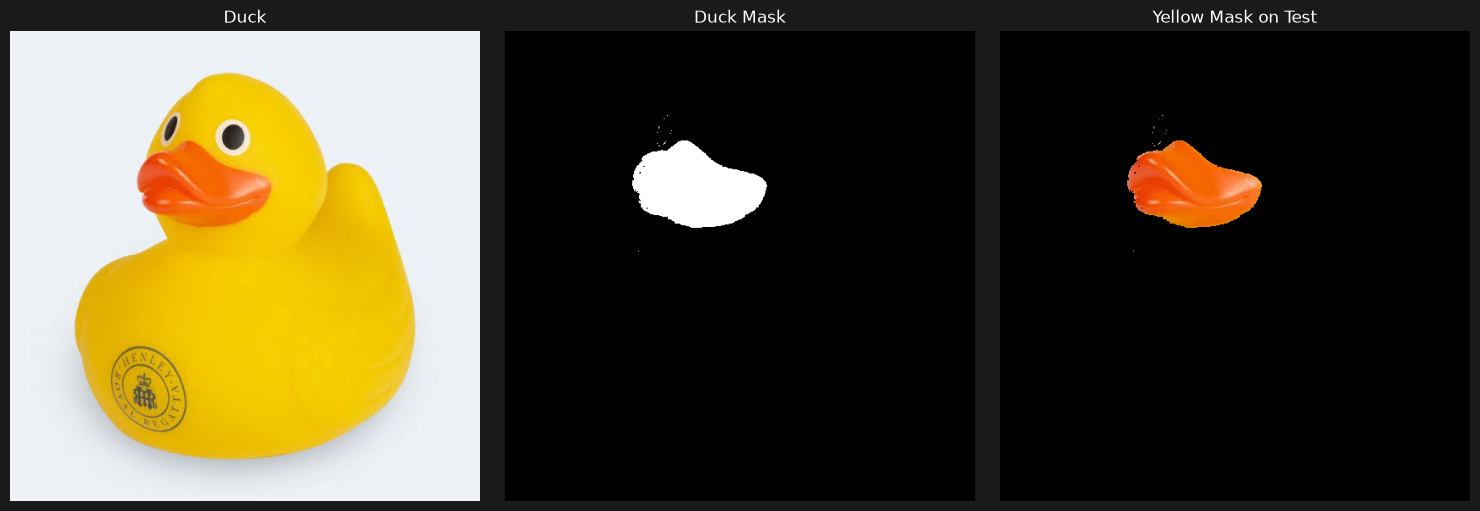

True

In [118]:
def create_mask(hsv,lower,upper):
    mask_cv2 = cv2.inRange(hsv, lower, upper)
    return mask_cv2

#lower_yellow =np.array([22,170,200])
#upper_yellow =np.array([27,255,255])

lower_yellow =np.array([6,100,200])
upper_yellow =np.array([18,255,255])

duck_yellow_binary = create_mask(
    duck_hsv,
    lower_yellow,
    upper_yellow
)


ducky_h, ducky_w = duck_img.shape[:2]

ducky_mask = cv2.resize(
    duck_yellow_binary,
    (ducky_w, ducky_h),
    interpolation=cv2.INTER_NEAREST
)

masked_duck_yellow = cv2.bitwise_and(
    duck_img,
    duck_img,
    mask=ducky_mask
)


fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(
    cv2.cvtColor(duck_img, cv2.COLOR_BGR2RGB)
)
axs[0].set_title("Duck")

axs[1].imshow(
    duck_yellow_binary,
    cmap="gray"
)
axs[1].set_title("Duck Mask")

axs[2].imshow(
    cv2.cvtColor(masked_duck_yellow, cv2.COLOR_BGR2RGB)
)
axs[2].set_title("Yellow Mask on Test")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()

cv2.imwrite("duck_yellow_mask.png", duck_yellow_binary)


# PART 3 — COLOR CHANNELS

A color image can be treated as:

`(H, W, C)`

For a 3-channel image, inspect and manipulate the channels separately.


## Exercise 7 — Split Channels

Use `cv2.split()`.

Display the three channels separately.

Compare their intensity distributions visually.


In [119]:
# TODO


## Exercise 8 — Manual Channel Indexing

Repeat the same idea using NumPy indexing.

Try:

```python
image[:, :, 0]
image[:, :, 1]
image[:, :, 2]
```

Remember that OpenCV uses **BGR** ordering.


In [120]:
# TODO


## Exercise 9 — Merge Channels

Create an altered image by modifying one channel and then merging the channels again with `cv2.merge()`.

Examples:

- suppress one channel
- increase one channel
- exchange two channels

Explain the visual effect.


In [121]:
# TODO


# PART 4 — HISTOGRAMS

A histogram describes the distribution of pixel intensities.

The source tutorial uses:

- grayscale histograms
- color histograms
- `cv2.calcHist()`


## Exercise 10 — Grayscale Histogram

1. Convert the image to grayscale.
2. Calculate its histogram.
3. Plot it.
4. Explain where the pixel intensities are concentrated.


In [122]:
# TODO


## Exercise 11 — Color Histograms

Calculate a histogram for each BGR channel.

Compare the three distributions.

Write one observation about the dominant channel or intensity range.


In [123]:
# TODO


## Exercise 12 — Histogram as a Diagnostic

Find two images with noticeably different exposure or lighting.

Plot their grayscale histograms.

Question:

How can a histogram help you decide whether thresholding or contrast adjustment might be useful?


In [124]:
# TODO


# PART 5 — HISTOGRAM EQUALIZATION

Histogram equalization redistributes intensity values to improve contrast in some images.

For grayscale images, OpenCV provides:

`cv2.equalizeHist()`


## Exercise 13 — Equalize a Grayscale Image

Compare:

- original grayscale
- equalized grayscale
- both histograms

Write one observation about contrast and one caution about using equalization.


In [125]:
# TODO


# PART 6 — BLURRING / FILTERING

The source tutorial discusses averaging, Gaussian blur, and median blur.

The practical idea:

> Smooth the image before later processing when noise or small variations are interfering with the task.


## Exercise 14 — Compare Blur Methods

Create:

- average blur
- Gaussian blur
- median blur

Display original + all three.

Write one sentence about which one preserves edges best in your example.


In [126]:
# TODO


## Exercise 15 — Blur Parameter Experiment

Choose one blur method.

Test at least three kernel sizes.

Change only the kernel size.

Record:

`kernel size | visual effect | useful / not useful`


In [127]:
# TODO


# PART 7 — THRESHOLDING

Thresholding converts intensity information into a simpler binary representation.

Explore:

- simple thresholding
- adaptive thresholding
- Otsu thresholding


## Exercise 16 — Simple Threshold

Try at least three threshold values.

Compare the masks.

Question:

What happens when the threshold becomes too low or too high?


In [128]:
# TODO


## Exercise 17 — Adaptive Threshold

Apply adaptive thresholding to an image where illumination is not uniform.

Compare it with a global threshold.

Write when adaptive thresholding appears more useful.


In [129]:
# TODO


## Exercise 18 — Otsu

Apply Otsu thresholding.

Compare:

- manually chosen threshold
- Otsu threshold

Write one sentence describing the difference.


In [130]:
# TODO


# PART 8 — IMAGE GRADIENTS

The source tutorial introduces:

- Sobel
- Scharr
- Laplacian
- Canny

A gradient measures how quickly pixel intensity changes spatially; large changes are often associated with edges.


## Exercise 19 — Sobel X / Y

Calculate horizontal and vertical gradients.

Display:

- grayscale
- Sobel X
- Sobel Y

Explain what kind of boundaries each emphasizes.


In [131]:
# TODO


## Exercise 20 — Laplacian

Apply Laplacian edge/gradient detection.

Compare its result with Sobel.

Write one limitation you notice.


In [132]:
# TODO


# PART 9 — CANNY EDGE DETECTION

Canny is a multi-stage edge detector. In practice, the two thresholds strongly affect the result.


## Exercise 21 — Canny Parameter Search

Try at least three threshold pairs.

Compare:

- too many edges
- too few edges
- useful result

Save your best result.


In [133]:
# TODO


## Exercise 22 — Blur Before Canny

Compare:

`grayscale → Canny`

versus:

`grayscale → Gaussian blur → Canny`

Explain why blur can sometimes improve the edge map.


In [134]:
# TODO


# PART 10 — CONTOURS

Contours represent boundaries of objects/regions.

They can be used to estimate:

- area
- perimeter
- shape
- position
- bounding boxes


## Exercise 23 — Find Contours

Use a binary image and `cv2.findContours()`.

Print:

- number of contours
- area of each contour

Draw the contours on a copy of the image.


In [135]:
# TODO


## Exercise 24 — Filter by Area

Ignore contours below a chosen area threshold.

Display:

- all contours
- filtered contours

Explain why area filtering can remove small noise.


In [136]:
# TODO


## Exercise 25 — Bounding Boxes

For filtered contours:

1. compute bounding rectangles,
2. draw the rectangles,
3. print coordinates and area.

This is a classical-CV bridge to future object detection.


In [137]:
# TODO


# PART 11 — GEOMETRIC TRANSFORMATIONS

The source tutorial covers:

- translation
- rotation
- resizing
- flipping
- cropping



## Exercise 26 — Translation

Move the image horizontally and vertically.

Compare:

- original
- translated image

Record the translation matrix conceptually.


In [138]:
# TODO


## Exercise 27 — Rotation

Rotate the image by:

- 90°
- 180°
- a custom angle

Compare the output dimensions.


In [139]:
# TODO


## Exercise 28 — Resize

Create:

- 25%
- 50%
- 100%
- 150%

Use the original dimensions rather than hard-coding all target dimensions.


In [140]:
# TODO


## Exercise 29 — Flip

Create:

- horizontal flip
- vertical flip
- both axes if desired

Explain which spatial axis is being reversed.


In [141]:
# TODO


## Exercise 30 — Crop

Use NumPy slicing.

Create a crop from a meaningful area and save it.

Remember:

`image[y1:y2, x1:x2]`



In [142]:
# TODO


# PART 12 — MORPHOLOGICAL OPERATIONS

The source tutorial introduces:

- erosion
- dilation
- opening
- closing
- morphological gradient

These are commonly applied to binary images.

Think:

- erosion → shrink/remove small foreground regions
- dilation → expand foreground regions
- opening → erosion followed by dilation
- closing → dilation followed by erosion


## Exercise 31 — Erosion vs Dilation

Apply both to the same binary mask.

Compare:

- object size
- small noise
- gaps


In [143]:
# TODO


## Exercise 32 — Opening vs Closing

Apply opening and closing.

Write:

- which one removes small isolated regions?
- which one tends to fill small gaps?


In [144]:
# TODO


# PART 13 — BITWISE IMAGE OPERATIONS

The source tutorial covers:

- AND
- OR
- NOT
- XOR

These become especially useful with masks.


## Exercise 33 — Bitwise Mask Operations

Create two simple masks.

Experiment with:

- `bitwise_and`
- `bitwise_or`
- `bitwise_not`
- `bitwise_xor`

Draw or display the results.

Explain the visual meaning of each operation.


In [145]:
# TODO


# PART 14 — ADVANCED COLOR SPACE PRACTICE

The source tutorial introduces RGB and HSV as useful color representations for histograms and image analysis.

## Exercise 34 — BGR → HSV

Convert the image to HSV.

Inspect:

- shape
- dtype
- one pixel

Explain what Hue, Saturation, and Value represent at a high level.


In [146]:
# TODO


## Exercise 35 — Simple Color-Based Mask

Use HSV to isolate a simple color range.

Display:

- original
- mask
- masked result

Do not aim for perfection; focus on understanding the pipeline.


In [147]:
# TODO


# PART 15 — MINI CV PIPELINES

## Exercise 36 — Pipeline A: Clean Edge Extraction

Build:

`read → BGR→gray → blur → Canny → save`

Print the shape after each major step.


In [148]:
# TODO


## Exercise 37 — Pipeline B: Object Candidates

Build:

`read → gray → threshold → morphology → contours → area filter → bounding boxes`

Goal:

Produce candidate regions rather than a perfect object detector.


In [149]:
# TODO


## Exercise 38 — Pipeline C: Architectural Evidence

Use an architectural / urban image.

Try to highlight at least one:

- facade boundary
- window region
- road boundary
- large rectangular region
- repetitive structure

Write:

**Problem → preprocessing → operation → result → limitation**


In [150]:
# TODO


# PART 16 — CONTROLLED EXPERIMENT

## Exercise 39 — Change One Variable

Pick one stage:

- threshold
- blur
- Canny
- morphology

Change only one parameter across three runs.

Create a tiny experiment table:

`parameter | output quality | observation`

Then choose the best setting and explain why.


In [151]:
# TODO


# PART 17 — R&D-STYLE VISUAL REPORT

## Exercise 40 — Compare Approaches

Choose one visual problem and compare **two approaches**.

Example:

- Threshold A vs Otsu
- Canny with blur vs without blur
- Morphology opening vs no opening
- RGB mask vs HSV mask

For each approach record:

- method
- parameters
- output
- limitation
- preferred approach

This is your first small controlled CV experiment.


In [152]:
# TODO


# FINAL — NO-AI OPEN-CODE CHALLENGE

Close the examples.

Start from an empty cell and choose one real image.

Build your own small OpenCV pipeline without asking AI for the complete code first.

Requirements:

1. image loading
2. color conversion
3. geometric operation
4. one image-processing operation
5. one analysis step
6. saved output

Then write:

### Problem
What visual question were you trying to answer?

### Approach
What operations did you choose and why?

### Result
What worked?

### Failure / Limitation
What did not work?

### Next Experiment
What would you change next?

This follows the Month 1 R&D habit:

**problem → baseline → experiment → observation → limitation → next experiment**


In [153]:
# TODO — start from an empty solution


# QUICK RECALL

Explain these without looking them up:

- `cv2.imread`
- `cv2.imwrite`
- BGR vs RGB
- grayscale
- `(H, W, C)`
- image masking
- channel splitting / merging
- grayscale histogram
- color histogram
- histogram equalization
- Gaussian blur
- median blur
- simple / adaptive / Otsu thresholding
- Sobel
- Laplacian
- Canny
- contours
- translation
- rotation
- resize
- flip
- crop
- erosion
- dilation
- opening
- closing
- bitwise operations
- HSV

### Success test

Can you open a blank Python file, take an image, preprocess it, inspect it, transform it, extract something useful, and save the result without relying on a full AI-generated solution?


# Source note

The concept sequence in this workbook was adapted from the uploaded Kaggle notebook:

**OpenCV Tutorial: From Basic to Advanced**

https://www.kaggle.com/code/talhabu/opencv-tutorial-from-basic-to-advanced

Use the source notebook as a reference, but keep this workbook as the active practice environment.
